In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("heart_data.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# Exploratory Data Analysis and Data Cleaning

In [3]:
df.shape

(918, 12)

In [4]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [6]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

<Axes: xlabel='HeartDisease'>

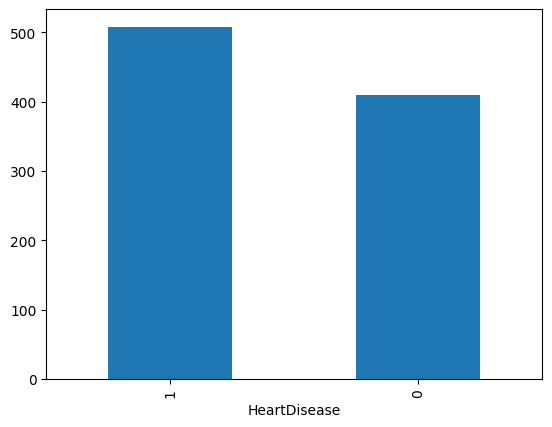

In [9]:
df['HeartDisease'].value_counts().plot(kind="bar")

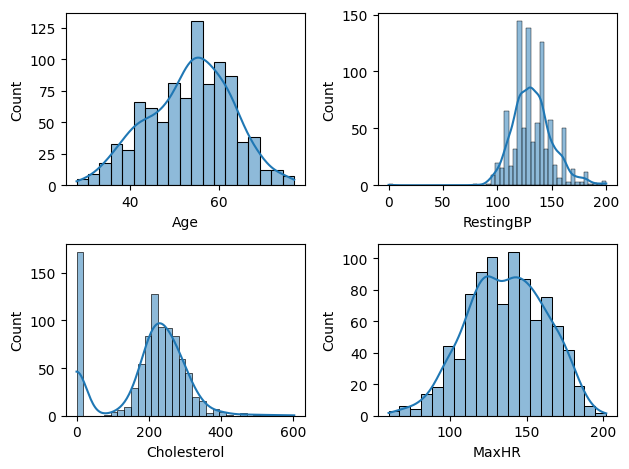

In [10]:
def plotting(plot, num):
  plt.subplot(2, 2, num)
  sns.histplot(df[plot], kde=True)

plotting("Age", 1)
plotting("RestingBP", 2)
plotting("Cholesterol", 3)
plotting("MaxHR", 4)

plt.tight_layout()

In [11]:
df['Cholesterol'].value_counts()

Cholesterol
0      172
254     11
223     10
220     10
211      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64

In [12]:
# Replacing 0 with mean in Cholesterol
Cholesterol_mean = df.loc[df["Cholesterol"] != 0, "Cholesterol"].mean()
df["Cholesterol"] = df["Cholesterol"].replace(0, Cholesterol_mean)
df["Cholesterol"] = df["Cholesterol"].round(2)

In [13]:
# Replacing 0 with mean in RestingBP
RestingBP_mean = df.loc[df["RestingBP"] != 0, "RestingBP"].mean()
df["RestingBP"] = df["RestingBP"].replace(0, RestingBP_mean)
df["RestingBP"] = df["RestingBP"].round(2)

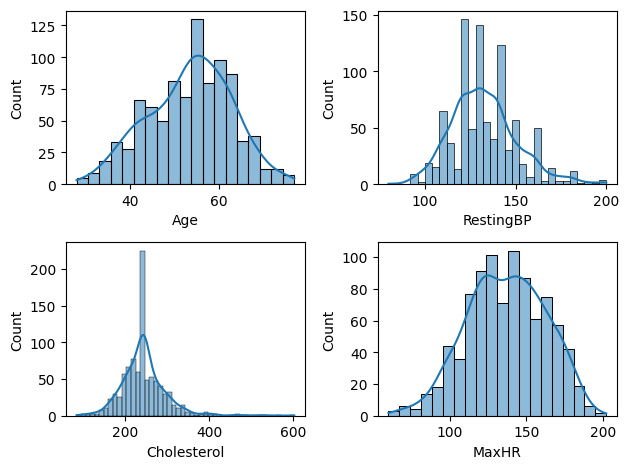

In [14]:
def plotting(var, num):
  plt.subplot(2, 2, num)
  sns.histplot(df[var], kde=True)

plotting("Age", 1)
plotting("RestingBP", 2)
plotting("Cholesterol", 3)
plotting("MaxHR", 4)

plt.tight_layout()

<Axes: xlabel='Sex', ylabel='count'>

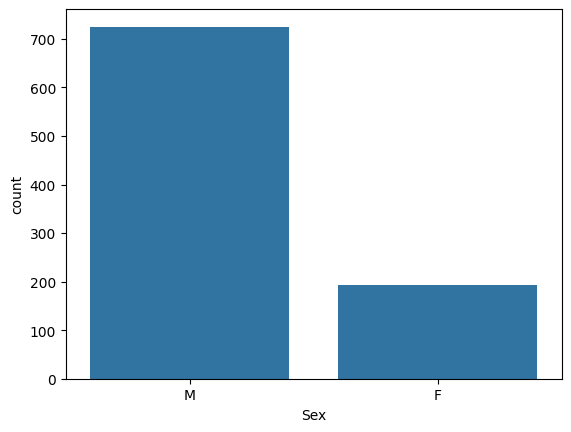

In [15]:
sns.countplot(x=df["Sex"])

<Axes: xlabel='ChestPainType', ylabel='count'>

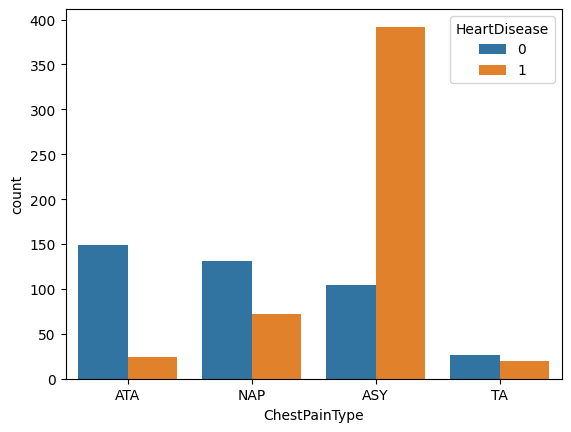

In [16]:
sns.countplot(x=df["ChestPainType"], hue= df["HeartDisease"])

<Axes: xlabel='Sex', ylabel='count'>

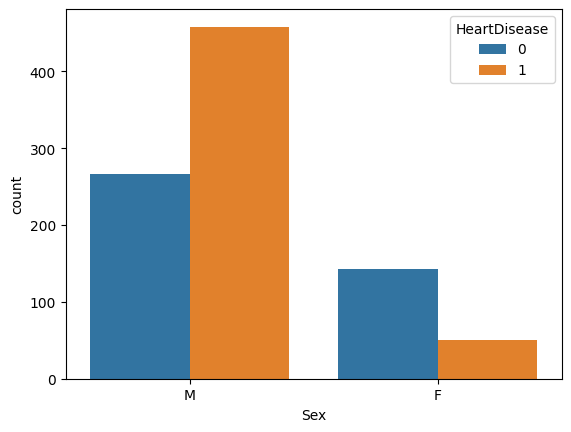

In [17]:
sns.countplot(x=df["Sex"], hue= df["HeartDisease"])

<Axes: xlabel='FastingBS', ylabel='count'>

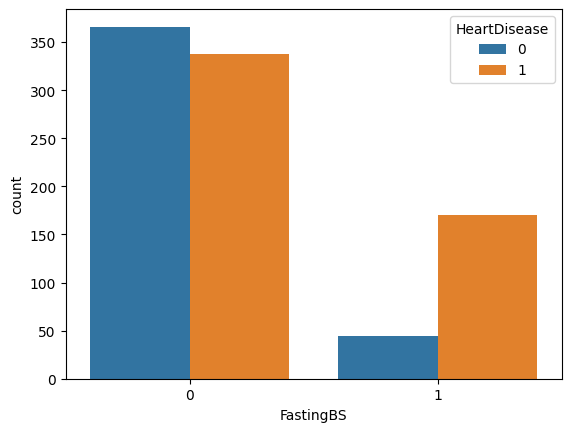

In [18]:
sns.countplot(x=df["FastingBS"], hue= df["HeartDisease"])

<Axes: >

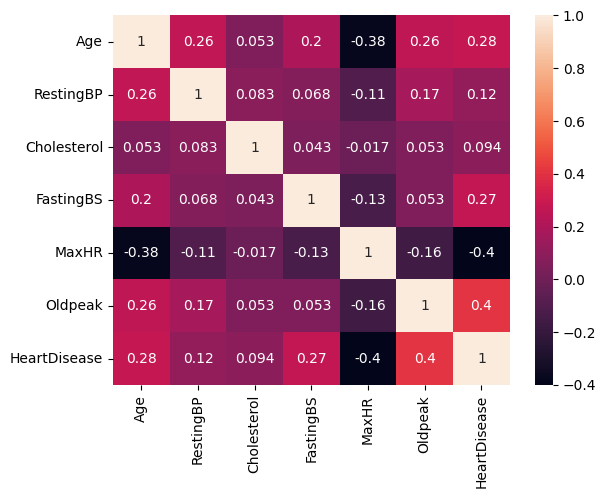

In [19]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

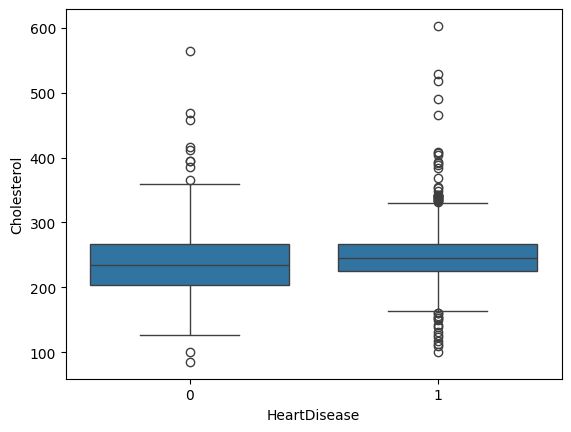

In [20]:
sns.boxplot(x = "HeartDisease", y = "Cholesterol", data=df)

<Axes: xlabel='HeartDisease', ylabel='Age'>

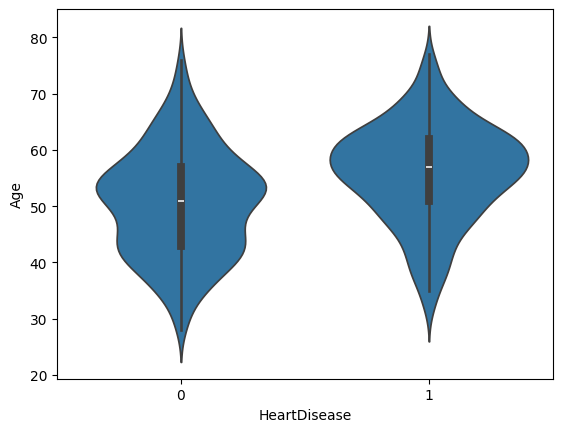

In [21]:
sns.violinplot(x='HeartDisease', y='Age', data=df)

# Data Preprocessing

In [22]:
encoded_df = pd.get_dummies(df,drop_first=True, dtype=int)
encoded_df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,1,1,0,0,1,0,0,0,1
1,49,160.0,180.0,0,156,1.0,1,0,0,1,0,1,0,0,1,0
2,37,130.0,283.0,0,98,0.0,0,1,1,0,0,0,1,0,0,1
3,48,138.0,214.0,0,108,1.5,1,0,0,0,0,1,0,1,1,0
4,54,150.0,195.0,0,122,0.0,0,1,0,1,0,1,0,0,0,1


In [23]:
from sklearn.preprocessing import StandardScaler
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
scaler = StandardScaler()
encoded_df[numerical_cols] = scaler.fit_transform(encoded_df[numerical_cols])
encoded_df.head()


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414853,0.832513,0,1.382928,-0.832432,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527192,-1.212938,0,0.754157,0.105664,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141317,0.719919,0,-1.525138,-0.832432,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303619,-0.574908,0,-1.132156,0.574711,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971022,-0.931454,0,-0.581981,-0.832432,0,1,0,1,0,1,0,0,0,1


In [24]:
encoded_df.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='str')

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

In [26]:
X = encoded_df.drop("HeartDisease", axis=1)
y = encoded_df["HeartDisease"]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
scaler = StandardScaler()
scaled_x_train = scaler.fit_transform(X_train)
scaled_x_test = scaler.fit_transform(X_test)

In [29]:
models = {
    "Logistic-Regression": LogisticRegression(),
    "KNN-Classifier": KNeighborsClassifier(),
    "Naive-Bayes": GaussianNB(),
    "Decision-Tree": DecisionTreeClassifier(),
    "SVM": SVC()
}

In [30]:
result = []

In [31]:
for name, model in models.items():
  model.fit(scaled_x_train, y_train)
  y_pred = model.predict(scaled_x_test)
  accuracy = accuracy_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  result.append({
      "Model": name,
      "Accuracy Score": accuracy * 100,
      "F1 Score": f1 * 100
  })

In [32]:
result

[{'Model': 'Logistic-Regression',
  'Accuracy Score': 86.41304347826086,
  'F1 Score': 88.03827751196172},
 {'Model': 'KNN-Classifier',
  'Accuracy Score': 85.32608695652173,
  'F1 Score': 87.08133971291866},
 {'Model': 'Naive-Bayes',
  'Accuracy Score': 85.32608695652173,
  'F1 Score': 86.82926829268293},
 {'Model': 'Decision-Tree',
  'Accuracy Score': 78.80434782608695,
  'F1 Score': 81.15942028985508},
 {'Model': 'SVM',
  'Accuracy Score': 84.78260869565217,
  'F1 Score': 86.79245283018868}]

In [33]:
import joblib
joblib.dump(models["Logistic-Regression"],"Logistic-Regression.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "columns.pkl")

['columns.pkl']